✅ statsmodels ready
  Dataset loaded : 1,000 rows  |  33 months
  Revenue column : Revenue(₹)

  PHARMA E-COMMERCE SALES FORECASTING SYSTEM  [v2 Improved]
  Inv-Error Ensemble | STL Seasonality | Validated Units
  Type 'exit' at any prompt to quit.

────────────────────────────────────────────────────────────
  SELECT FILTER COLUMN
────────────────────────────────────────────────────────────
  1.  Product_Name
  2.  Category
  3.  Season
────────────────────────────────────────────────────────────

  Available [Category] values:

     1.  Allergy
     2.  Antibiotics
     3.  Digestive
     4.  Pain Relief
     5.  Skincare
     6.  Vitamins


  Running forecast for [Category = Skincare] ...

  Weights → GM:79.7%  Roll:13.1%  SVR:7.2%

  FORECAST SUMMARY  |  Category: Skincare

  MODEL ACCURACY  (6-month holdout):

  Model                           MAE          RMSE      MAPE      Acc   Weight
  ----------------------  ------------  ------------  --------  -------  -------
  GM(1,1)   

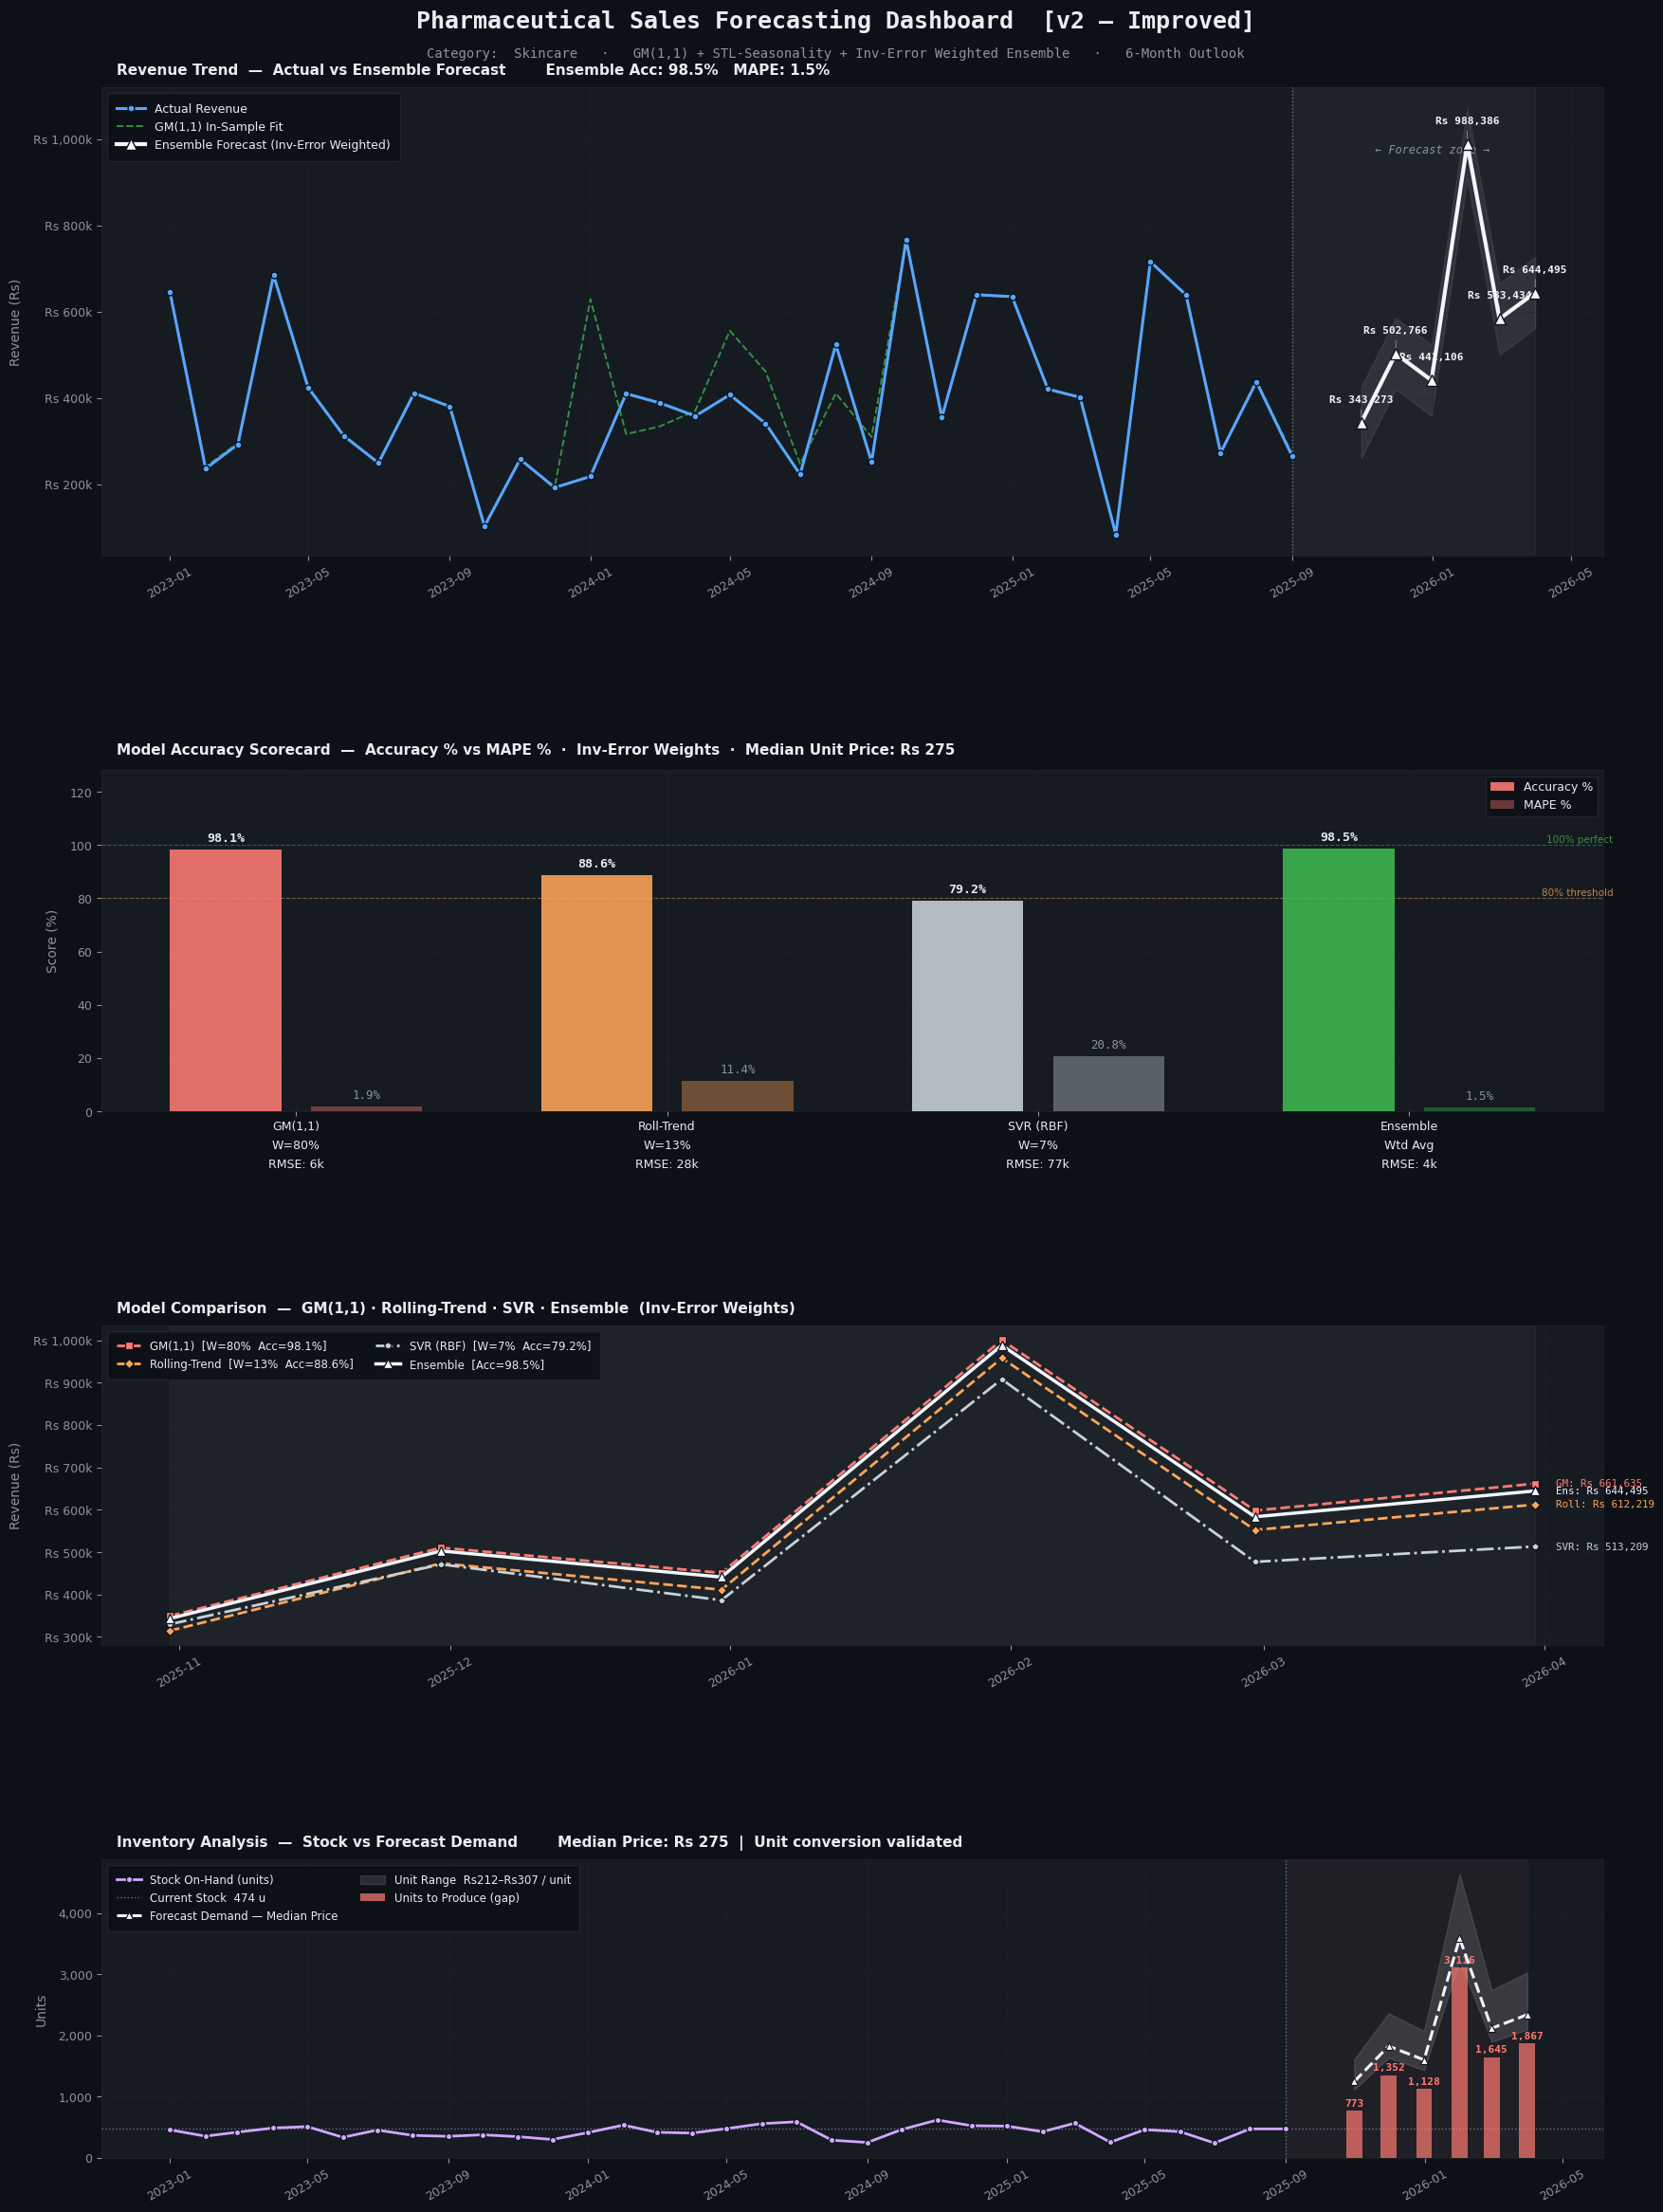

  Chart saved: pharma_forecast_v3.png
────────────────────────────────────────────────────────────
  What next?  [1] Forecast another   [2] Exit
────────────────────────────────────────────────────────────

────────────────────────────────────────────────────────────
  SELECT FILTER COLUMN
────────────────────────────────────────────────────────────
  1.  Product_Name
  2.  Category
  3.  Season
────────────────────────────────────────────────────────────

  Available [Product_Name] values:

     1.  Allergy Tablet
     2.  Amoxicillin
     3.  Antacid
     4.  Cough Syrup
     5.  Ibuprofen
     6.  Multivitamin
     7.  Pain Relief Gel
     8.  Paracetamol
     9.  Skincare Cream
    10.  Vitamin C


  Running forecast for [Product_Name = Vitamin C] ...

  Weights → GM:52.8%  Roll:30.3%  SVR:17.0%

  FORECAST SUMMARY  |  Product_Name: Vitamin C

  MODEL ACCURACY  (6-month holdout):

  Model                           MAE          RMSE      MAPE      Acc   Weight
  --------------------

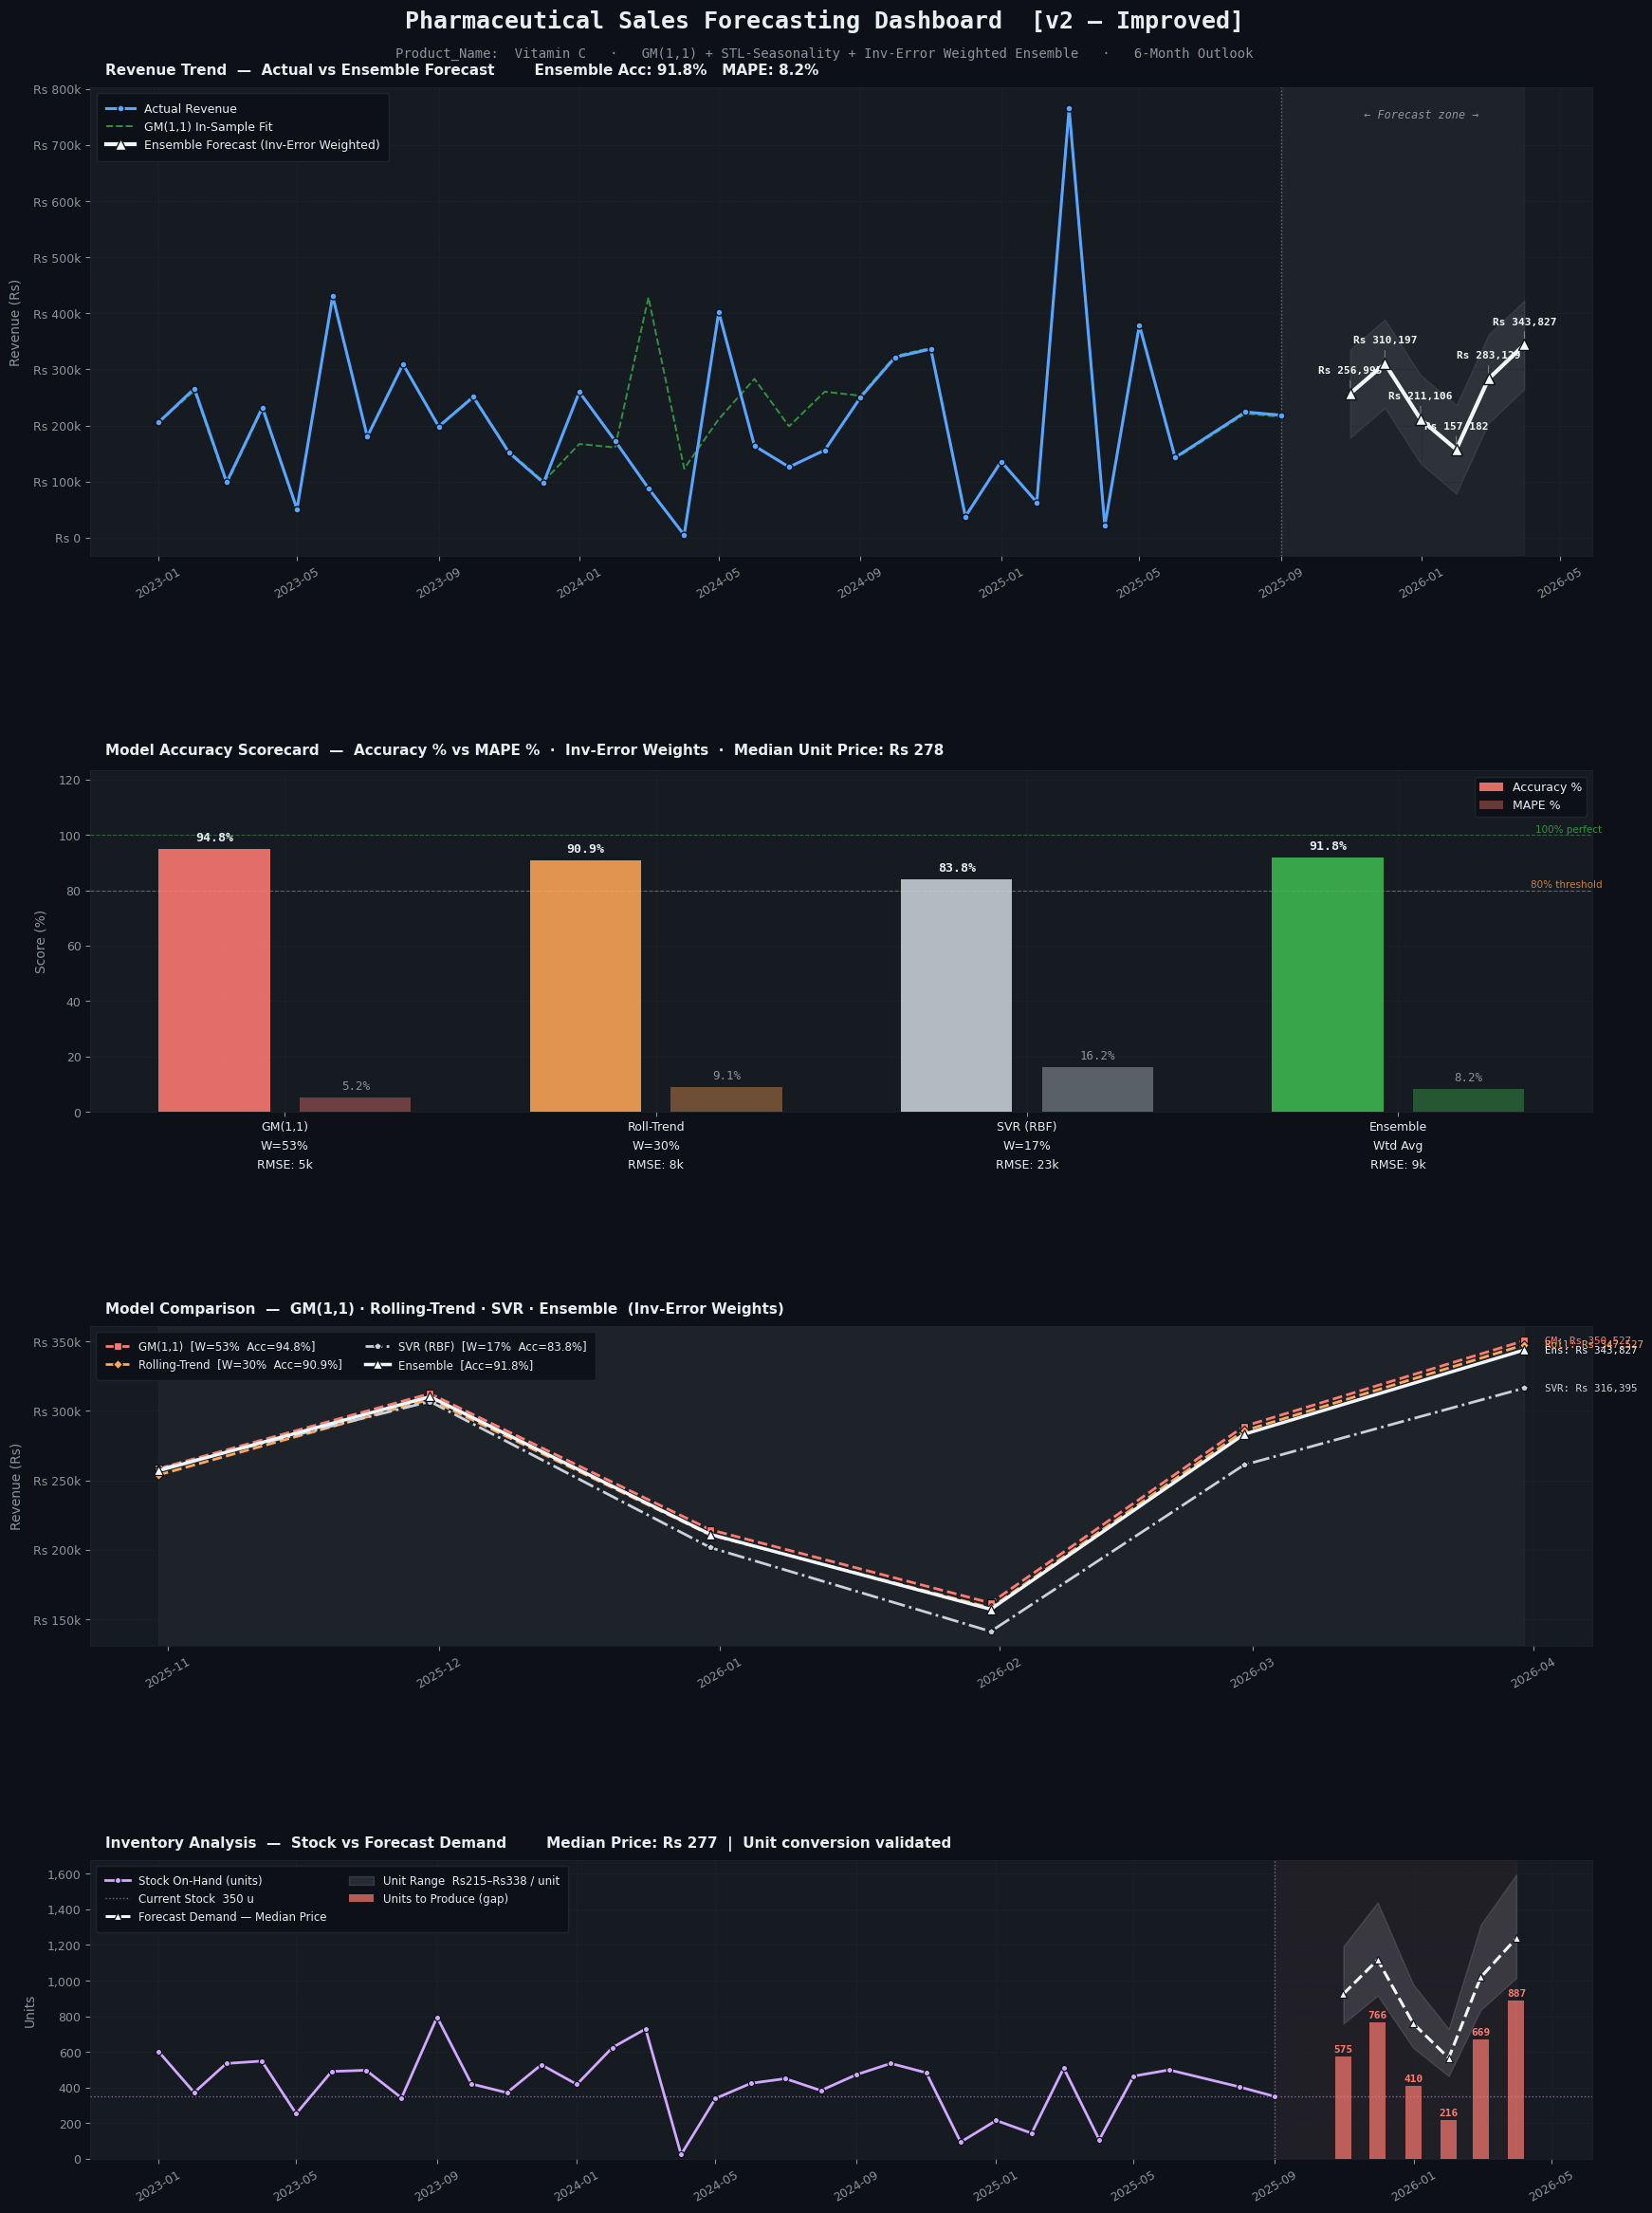

  Chart saved: pharma_forecast_v3.png
────────────────────────────────────────────────────────────
  What next?  [1] Forecast another   [2] Exit
────────────────────────────────────────────────────────────

  Goodbye!



In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
#   PHARMA E-COMMERCE SALES FORECASTING SYSTEM  [IMPROVED v2]
#   Final Year Project  |  GM(1,1) + Rolling-Trend + SVR Ensemble
#   Improvements:
#     1. MAPE/RMSE per model → inverse-error weighted ensemble
#     2. STL Seasonality decomposition → seasonal correction applied to forecasts
#     3. Validated unit conversion → median price with percentile bounds
# ═══════════════════════════════════════════════════════════════════════════════

import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "statsmodels", "-q"])
print("✅ statsmodels ready")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.seasonal import STL

# ─────────────────────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────────────────────
DATASET_FILE  = "Pharma_Dataset_With_Stock.xlsx"
SALES_COL     = "Revenue(Rs)"
UNITS_COL     = "Units_Sold"
STOCK_COL     = "Remaining_Stock"
VALID_COLUMNS = ["Product_Name", "Category", "Season"]
N_FORECAST    = 6
DIVIDER       = "─" * 60

C_BG      = "#0d1117"
C_PANEL   = "#161b22"
C_GRID    = "#21262d"
C_TEXT    = "#e6edf3"
C_MUTED   = "#8b949e"
C_ACTUAL  = "#58a6ff"
C_FIT     = "#3fb950"
C_GM      = "#ff7b72"
C_ROLL    = "#ffa657"
C_ENS     = "#f0f6fc"
C_SVR     = "#c9d1d9"
C_STOCK   = "#d2a8ff"
C_NEED    = "#ff7b72"
C_SAFE    = "#3fb950"
C_SEASON  = "#79c0ff"
C_ACC_BAR = ["#ff7b72", "#ffa657", "#c9d1d9", "#3fb950"]


# ─────────────────────────────────────────────────────────────────────────────
# STEP 1  Load & Preprocess
# ─────────────────────────────────────────────────────────────────────────────
def load_data():
    df = pd.read_excel(r"C:\Users\user\OneDrive\Desktop\project\Pharma_Dataset_With_Stock.xlsx")
    df.columns = df.columns.str.strip()
    df = df.loc[:, ~df.columns.duplicated()]
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df = df.dropna(subset=["Date"]).sort_values("Date").reset_index(drop=True)

    global SALES_COL
    for col in df.columns:
        if "revenue" in col.lower() or "sale" in col.lower():
            SALES_COL = col
            break

    df[SALES_COL] = pd.to_numeric(df[SALES_COL], errors="coerce").ffill()
    df[UNITS_COL] = pd.to_numeric(df[UNITS_COL], errors="coerce").ffill()

    if STOCK_COL not in df.columns:
        np.random.seed(42)
        df[STOCK_COL] = np.random.randint(100, 900, len(df))
    else:
        df[STOCK_COL] = pd.to_numeric(df[STOCK_COL], errors="coerce").ffill()

    df["Month"] = df["Date"].dt.to_period("M")
    print(f"  Dataset loaded : {df.shape[0]:,} rows  |  {df['Month'].nunique()} months")
    print(f"  Revenue column : {SALES_COL}")
    return df


# ─────────────────────────────────────────────────────────────────────────────
# STL Seasonality Decomposition
# ─────────────────────────────────────────────────────────────────────────────
def stl_decompose(ts, period=12):
    arr = np.array(ts, dtype=float)
    if len(arr) < 2 * period:
        return arr.copy(), np.zeros(len(arr)), np.zeros(N_FORECAST)
    stl = STL(arr, period=period, robust=True)
    res = stl.fit()
    trend    = res.trend
    seasonal = res.seasonal
    sf_future = np.array([seasonal[i % period] for i in
                           range(len(arr), len(arr) + N_FORECAST)])
    return trend, seasonal, sf_future


# ─────────────────────────────────────────────────────────────────────────────
# GM(1,1) Grey Model
# ─────────────────────────────────────────────────────────────────────────────
def gm11(x0, n_fc):
    x0 = np.array(x0, dtype=float)
    x0 = np.where(x0 <= 0, 1.0, x0)
    n  = len(x0)
    x1 = np.cumsum(x0)
    z1 = (x1[:-1] + x1[1:]) / 2.0
    B  = np.column_stack((-z1, np.ones(n - 1)))
    a, b = np.linalg.lstsq(B, x0[1:], rcond=None)[0]

    def f(k):
        return (x0[0] - b / a) * np.exp(-a * k) + b / a

    x1p    = np.array([f(i) for i in range(n + n_fc)])
    x0p    = np.diff(x1p)
    insamp = np.concatenate([[x0[0]], x0p[:n - 1]])
    fc     = np.maximum(0.0, x0p[n - 1:])
    return insamp, fc


# ─────────────────────────────────────────────────────────────────────────────
# Rolling-Trend Model
# ─────────────────────────────────────────────────────────────────────────────
def rolling_trend(data, steps=6, window=6):
    data  = np.array(data, dtype=float)
    n     = len(data)
    w     = min(window, n)
    mu    = float(np.mean(data[-w:]))
    if w > 1:
        raw   = (float(data[-1]) - float(data[-w])) / (w - 1)
        trend = float(np.clip(raw, -mu * 0.25, mu * 0.25))
    else:
        trend = 0.0
    return np.maximum(0.0, np.array([mu + trend * (i + 1) for i in range(steps)]))


# ─────────────────────────────────────────────────────────────────────────────
# SVR Model
# ─────────────────────────────────────────────────────────────────────────────
def svr_forecast(data, steps=6, window=12):
    from sklearn.svm import SVR
    from sklearn.preprocessing import MinMaxScaler

    data = np.array(data, dtype=float)
    n    = len(data)
    w    = min(window, n - 1)

    X, y = [], []
    for i in range(w, n):
        X.append(data[i - w:i])
        y.append(data[i])
    X, y = np.array(X), np.array(y)

    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    X_sc = scaler_X.fit_transform(X)
    y_sc = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

    model = SVR(kernel="rbf", C=100, epsilon=0.01, gamma="scale")
    model.fit(X_sc, y_sc)

    history = list(data[-w:])
    preds   = []
    for _ in range(steps):
        x_in = np.array(history[-w:]).reshape(1, -1)
        x_sc = scaler_X.transform(x_in)
        y_p  = scaler_y.inverse_transform(model.predict(x_sc).reshape(-1, 1))[0, 0]
        y_p  = max(0.0, float(y_p))
        preds.append(y_p)
        history.append(y_p)

    return np.array(preds)


# ─────────────────────────────────────────────────────────────────────────────
# Evaluation Metrics
# ─────────────────────────────────────────────────────────────────────────────
def calc_metrics(actual, pred):
    a = np.array(actual, dtype=float)
    p = np.array(pred,   dtype=float)
    mae  = float(mean_absolute_error(a, p))
    rmse = float(np.sqrt(mean_squared_error(a, p)))
    mape = float(np.mean(np.abs((a - p) / (a + 1e-6))) * 100.0)
    acc  = max(0.0, 100.0 - mape)
    return dict(mae=mae, rmse=rmse, mape=mape, acc=acc)


# ─────────────────────────────────────────────────────────────────────────────
# Inverse-Error Weighted Ensemble
# ─────────────────────────────────────────────────────────────────────────────
def compute_inv_error_weights(m_gm, m_roll, m_svr):
    mapes = np.array([m_gm["mape"], m_roll["mape"], m_svr["mape"]], dtype=float)
    mapes = np.where(mapes < 0.001, 0.001, mapes)
    inv   = 1.0 / mapes
    w     = inv / inv.sum()
    return float(w[0]), float(w[1]), float(w[2])


def ensemble(gm_fc, roll_fc, svr_fc, w_gm=0.45, w_roll=0.20, w_svr=0.35):
    return (w_gm  * np.array(gm_fc)
          + w_roll * np.array(roll_fc)
          + w_svr  * np.array(svr_fc))


# ─────────────────────────────────────────────────────────────────────────────
# Validated Unit Conversion
# ─────────────────────────────────────────────────────────────────────────────
def validated_unit_conversion(grp, ens_fc):
    rev_arr     = grp["Revenue"].values.astype(float)
    unit_arr    = grp["Units"].values.astype(float)
    unit_prices = rev_arr / np.maximum(unit_arr, 1)

    median_price = float(np.median(unit_prices))
    p25_price    = float(np.percentile(unit_prices, 25))
    p75_price    = float(np.percentile(unit_prices, 75))

    ens_units = ens_fc / max(median_price, 1.0)
    units_lo  = ens_fc / max(p75_price, 1.0)
    units_hi  = ens_fc / max(p25_price, 1.0)

    return ens_units, units_lo, units_hi, median_price, p25_price, p75_price


# ─────────────────────────────────────────────────────────────────────────────
# Monthly aggregation
# ─────────────────────────────────────────────────────────────────────────────
def build_monthly(df, column, value):
    sub = df[df[column] == value].copy()
    grp = sub.groupby("Month").agg(
        Revenue=(SALES_COL, "sum"),
        Units  =(UNITS_COL, "sum"),
        Stock  =(STOCK_COL, "mean"),
    ).reset_index()
    grp.index = grp["Month"].dt.to_timestamp()
    return grp.sort_index()


# ─────────────────────────────────────────────────────────────────────────────
# Console Summary
# ─────────────────────────────────────────────────────────────────────────────
def print_summary(grp, future_dates, out, meta):
    gm_fc   = out["gm_fc"]
    roll_fc = out["roll_fc"]
    svr_fc  = out["svr_fc"]
    ens_fc  = out["ens_fc"]
    m_gm    = meta["m_gm"]
    m_roll  = meta["m_roll"]
    m_svr   = meta["m_svr"]
    m_ens   = meta["m_ens"]
    w_gm    = meta["w_gm"]
    w_roll  = meta["w_roll"]
    w_svr   = meta["w_svr"]

    ens_units, units_lo, units_hi, med_p, p25_p, p75_p = validated_unit_conversion(grp, ens_fc)
    cur_stock = float(grp["Stock"].values[-1])
    need      = np.maximum(0.0, ens_units - cur_stock)

    print(f"\n{'='*60}")
    print(f"  FORECAST SUMMARY  |  {meta['column']}: {meta['value']}")
    print(f"{'='*60}")
    print(f"\n  MODEL ACCURACY  (6-month holdout):\n")
    print(f"  {'Model':<22} {'MAE':>12}  {'RMSE':>12}  {'MAPE':>8}  {'Acc':>7}  {'Weight':>7}")
    print(f"  {'-'*22}  {'-'*12}  {'-'*12}  {'-'*8}  {'-'*7}  {'-'*7}")
    for lbl, m, w in [
        ("GM(1,1)",        m_gm,  w_gm),
        ("Rolling-Trend",  m_roll, w_roll),
        ("SVR",            m_svr,  w_svr),
        ("Ensemble(Best)", m_ens,  None),
    ]:
        wstr = f"{w*100:.1f}%" if w is not None else "—"
        print(f"  {lbl:<22} Rs{m['mae']:>10,.0f}  Rs{m['rmse']:>10,.0f}"
              f"  {m['mape']:>7.1f}%  {m['acc']:>6.1f}%  {wstr:>7}")

    print(f"\n  ENSEMBLE WEIGHTS:  GM={w_gm*100:.1f}%  Roll={w_roll*100:.1f}%  SVR={w_svr*100:.1f}%")
    print(f"\n  UNIT PRICE VALIDATION:")
    print(f"    Median: Rs {med_p:,.0f}  |  P25: Rs {p25_p:,.0f}  |  P75: Rs {p75_p:,.0f}")

    print(f"\n  6-MONTH REVENUE FORECAST:\n")
    print(f"  {'Month':<10}  {'GM(1,1)':>12}  {'Rolling':>12}  {'SVR':>12}  {'Ensemble':>12}  {'Units':>8}")
    print(f"  {'-'*10}  {'-'*12}  {'-'*12}  {'-'*12}  {'-'*12}  {'-'*8}")
    for d, g, r, s, e, u in zip(future_dates, gm_fc, roll_fc, svr_fc, ens_fc, ens_units):
        print(f"  {d.strftime('%b %Y'):<10}  Rs{g:>10,.0f}  Rs{r:>10,.0f}"
              f"  Rs{s:>10,.0f}  Rs{e:>10,.0f}  {u:>8,.0f}")

    print(f"\n  INVENTORY  (current stock = {cur_stock:,.0f} units):\n")
    for d, u, n in zip(future_dates, ens_units, need):
        st = "!! SHORTAGE" if n > 0 else "OK"
        print(f"  {d.strftime('%b %Y')}  demand={u:,.0f}  need={n:,.0f}  {st}")
    print(f"\n{'='*60}\n")


# ─────────────────────────────────────────────────────────────────────────────
# FINAL PLOT  –  4 panels, clean dark theme
# ─────────────────────────────────────────────────────────────────────────────
def draw_plot(grp, future_dates, out, meta):
    gm_insamp = out["gm_insamp"]
    gm_fc     = out["gm_fc"]
    roll_fc   = out["roll_fc"]
    svr_fc    = out["svr_fc"]
    ens_fc    = out["ens_fc"]
    seasonal  = out["seasonal"]

    ts_rev   = grp["Revenue"].values.astype(float)
    ts_stock = grp["Stock"].values.astype(float)
    idx      = grp.index

    ens_units, units_lo, units_hi, med_price, p25_p, p75_p = \
        validated_unit_conversion(grp, ens_fc)
    cur_stock = float(ts_stock[-1])
    need      = np.maximum(0.0, ens_units - cur_stock)
    ci_std    = float(np.std(ts_rev - gm_insamp))

    m_gm   = meta["m_gm"]
    m_roll = meta["m_roll"]
    m_svr  = meta["m_svr"]
    m_ens  = meta["m_ens"]
    w_gm   = meta["w_gm"]
    w_roll = meta["w_roll"]
    w_svr  = meta["w_svr"]

    # ── Figure layout ─────────────────────────────────────────────────────
    plt.style.use("dark_background")
    fig = plt.figure(figsize=(18, 24), facecolor=C_BG)
    gs  = gridspec.GridSpec(
        4, 1, figure=fig,
        height_ratios=[2.2, 1.6, 1.5, 1.4],
        hspace=0.60,
        left=0.07, right=0.95, top=0.95, bottom=0.04
    )
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1])
    ax3 = fig.add_subplot(gs[2])
    ax4 = fig.add_subplot(gs[3])

    def _style(ax):
        ax.set_facecolor(C_PANEL)
        ax.grid(True, color=C_GRID, linewidth=0.6, linestyle="--", alpha=0.7)
        ax.set_axisbelow(True)
        for sp in ax.spines.values():
            sp.set_color(C_GRID)
            sp.set_linewidth(0.5)
        ax.tick_params(colors=C_MUTED, labelsize=9)
        ax.xaxis.label.set_color(C_MUTED)
        ax.yaxis.label.set_color(C_MUTED)

    for ax in (ax1, ax2, ax3, ax4):
        _style(ax)

    # Suptitle
    fig.text(0.5, 0.976,
             "Pharmaceutical Sales Forecasting Dashboard  [v2 — Improved]",
             ha="center", fontsize=18, fontweight="bold",
             color=C_TEXT, fontfamily="monospace")
    fig.text(0.5, 0.963,
             f"{meta['column']}:  {meta['value']}   ·   "
             f"GM(1,1) + STL-Seasonality + Inv-Error Weighted Ensemble   ·   6-Month Outlook",
             ha="center", fontsize=10, color=C_MUTED, fontfamily="monospace")

    # ══════════════════════════════════════════════════════════════════════
    # PANEL 1 — Revenue Trend
    # ══════════════════════════════════════════════════════════════════════
    ci_lo = np.maximum(0, ens_fc - ci_std)
    ci_hi = ens_fc + ci_std
    ax1.fill_between(future_dates, ci_lo, ci_hi,
                     color=C_ENS, alpha=0.08, zorder=0)

    ax1.plot(idx, ts_rev,
             color=C_ACTUAL, linewidth=2.2, zorder=5,
             marker="o", markersize=5,
             markerfacecolor=C_ACTUAL, markeredgecolor=C_BG, markeredgewidth=1.0,
             label="Actual Revenue")

    ax1.plot(idx, gm_insamp,
             color=C_FIT, linewidth=1.4, linestyle="--", alpha=0.75, zorder=4,
             label="GM(1,1) In-Sample Fit")

    ax1.axvline(idx[-1], color=C_MUTED, linewidth=1.0,
                linestyle=":", alpha=0.7, zorder=3)
    ax1.axvspan(idx[-1], future_dates[-1],
                alpha=0.04, color=C_ENS, zorder=0)

    ymax = max(float(ts_rev.max()), float(ens_fc.max()))
    ax1.text(future_dates[0], ymax * 1.00,
             "  ← Forecast zone →", color=C_MUTED, fontsize=8.5,
             va="top", fontfamily="monospace", style="italic")

    ax1.plot(future_dates, ens_fc,
             color=C_ENS, linewidth=3.0, zorder=6,
             marker="^", markersize=9,
             markerfacecolor=C_ENS, markeredgecolor=C_BG, markeredgewidth=1.0,
             label="Ensemble Forecast (Inv-Error Weighted)")

    for d, v in zip(future_dates, ens_fc):
        ax1.annotate(
            f"Rs {v:,.0f}",
            xy=(d, v),
            xytext=(0, 14), textcoords="offset points",
            ha="center", va="bottom", fontsize=8, color=C_ENS,
            fontfamily="monospace", fontweight="bold",
            arrowprops=dict(arrowstyle="-", color=C_ENS, lw=0.6, alpha=0.5)
        )

    ax1.set_title(
        f"Revenue Trend  —  Actual vs Ensemble Forecast"
        f"        Ensemble Acc: {m_ens['acc']:.1f}%   MAPE: {m_ens['mape']:.1f}%",
        fontsize=11, color=C_TEXT, pad=10, fontweight="bold",
        loc="left", x=0.01)
    ax1.set_ylabel("Revenue (Rs)", fontsize=10, labelpad=8)
    ax1.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"Rs {x/1e3:,.0f}k"
                              if x >= 1000 else f"Rs {x:,.0f}"))
    ax1.tick_params(axis="x", rotation=30, labelsize=9)
    ax1.legend(loc="upper left", fontsize=9,
               facecolor=C_BG, edgecolor=C_GRID,
               labelcolor=C_TEXT, framealpha=0.95,
               handlelength=2.4, borderpad=0.8)

    # ══════════════════════════════════════════════════════════════════════
    # PANEL 2 — Model Accuracy Scorecard  (CLEAN, NO OVERLAP)
    # ══════════════════════════════════════════════════════════════════════
    models = ["GM(1,1)", "Roll-Trend", "SVR (RBF)", "Ensemble"]
    mapes  = [m_gm["mape"], m_roll["mape"], m_svr["mape"], m_ens["mape"]]
    accs   = [m_gm["acc"],  m_roll["acc"],  m_svr["acc"],  m_ens["acc"]]
    rmses  = [m_gm["rmse"], m_roll["rmse"], m_svr["rmse"], m_ens["rmse"]]
    wts    = [f"W={w_gm*100:.0f}%", f"W={w_roll*100:.0f}%",
              f"W={w_svr*100:.0f}%", "Wtd Avg"]

    x         = np.arange(len(models))
    bar_w     = 0.30   # each bar width
    gap       = 0.08   # gap between Acc and MAPE bar per group

    bars_acc  = ax2.bar(x - (bar_w + gap) / 2, accs,  bar_w,
                        color=C_ACC_BAR, alpha=0.88, zorder=4, label="Accuracy %")
    bars_mape = ax2.bar(x + (bar_w + gap) / 2, mapes, bar_w,
                        color=C_ACC_BAR, alpha=0.38, zorder=4, label="MAPE %")

    # ── Labels above bars — enough padding so they never touch ────────────
    y_top = max(accs + mapes)
    for bar, val in zip(bars_acc, accs):
        cx = bar.get_x() + bar.get_width() / 2.0
        ax2.text(cx, bar.get_height() + y_top * 0.02,
                 f"{val:.1f}%",
                 ha="center", va="bottom", fontsize=9.5,
                 color=C_TEXT, fontweight="bold", fontfamily="monospace")

    for bar, val in zip(bars_mape, mapes):
        cx = bar.get_x() + bar.get_width() / 2.0
        ax2.text(cx, bar.get_height() + y_top * 0.02,
                 f"{val:.1f}%",
                 ha="center", va="bottom", fontsize=9,
                 color=C_MUTED, fontfamily="monospace")

    # ── X-tick labels: model name + weight + RMSE on separate lines ───────
    xtick_labels = [
        f"{m}\n{wl}\nRMSE: {r/1e3:,.0f}k"
        for m, wl, r in zip(models, wts, rmses)
    ]
    ax2.set_xticks(x)
    ax2.set_xticklabels(xtick_labels, fontsize=9, color=C_TEXT,
                        linespacing=1.7)

    # ── Y-axis and limits ─────────────────────────────────────────────────
    ax2.set_ylabel("Score (%)", fontsize=10, labelpad=8)
    ax2.set_ylim(0, y_top * 1.30)   # 30% headroom so labels never clip

    # ── Title (standalone, above bars — no overlap) ───────────────────────
    ax2.set_title(
        f"Model Accuracy Scorecard  —  Accuracy % vs MAPE %  ·  "
        f"Inv-Error Weights  ·  Median Unit Price: Rs {meta['med_price']:,.0f}",
        fontsize=11, color=C_TEXT, pad=12, fontweight="bold",
        loc="left", x=0.01)

    # ── Legend top-right ──────────────────────────────────────────────────
    ax2.legend(loc="upper right", fontsize=9,
               facecolor=C_BG, edgecolor=C_GRID,
               labelcolor=C_TEXT, framealpha=0.95)

    # ── Reference lines ───────────────────────────────────────────────────
    ax2.axhline(100, color=C_SAFE,  linewidth=0.8, linestyle="--", alpha=0.45)
    ax2.axhline(80,  color=C_ROLL,  linewidth=0.8, linestyle="--", alpha=0.45)
    ax2.text(3.55, 100 + y_top * 0.01, "100% perfect",
             fontsize=7.5, color=C_SAFE, alpha=0.75, ha="right")
    ax2.text(3.55, 80  + y_top * 0.01, "80% threshold",
             fontsize=7.5, color=C_ROLL, alpha=0.75, ha="right")

    # ══════════════════════════════════════════════════════════════════════
    # PANEL 3 — Model Comparison
    # ══════════════════════════════════════════════════════════════════════
    ax3.plot(future_dates, gm_fc,
             color=C_GM, linewidth=2.0, linestyle="--", zorder=4,
             marker="s", markersize=6,
             markerfacecolor=C_GM, markeredgecolor=C_BG, markeredgewidth=0.9,
             label=f"GM(1,1)  [W={w_gm*100:.0f}%  Acc={m_gm['acc']:.1f}%]")

    ax3.plot(future_dates, roll_fc,
             color=C_ROLL, linewidth=2.0, linestyle="--", zorder=4,
             marker="D", markersize=5.5,
             markerfacecolor=C_ROLL, markeredgecolor=C_BG, markeredgewidth=0.9,
             label=f"Rolling-Trend  [W={w_roll*100:.0f}%  Acc={m_roll['acc']:.1f}%]")

    ax3.plot(future_dates, svr_fc,
             color=C_SVR, linewidth=2.0, linestyle="-.", zorder=4,
             marker="p", markersize=6,
             markerfacecolor=C_SVR, markeredgecolor=C_BG, markeredgewidth=0.9,
             label=f"SVR (RBF)  [W={w_svr*100:.0f}%  Acc={m_svr['acc']:.1f}%]")

    ax3.plot(future_dates, ens_fc,
             color=C_ENS, linewidth=2.5, zorder=6,
             marker="^", markersize=7,
             markerfacecolor=C_ENS, markeredgecolor=C_BG, markeredgewidth=0.9,
             label=f"Ensemble  [Acc={m_ens['acc']:.1f}%]")

    for fc, col, lbl in [
        (gm_fc, C_GM, "GM"), (roll_fc, C_ROLL, "Roll"),
        (svr_fc, C_SVR, "SVR"), (ens_fc, C_ENS, "Ens"),
    ]:
        ax3.annotate(
            f"  {lbl}: Rs {fc[-1]:,.0f}",
            xy=(future_dates[-1], fc[-1]),
            xytext=(6, 0), textcoords="offset points",
            fontsize=7.8, color=col, va="center",
            fontfamily="monospace"
        )

    ax3.axvspan(future_dates[0], future_dates[-1],
                alpha=0.04, color=C_ENS, zorder=0)
    ax3.set_title(
        "Model Comparison  —  GM(1,1) · Rolling-Trend · SVR · Ensemble  "
        "(Inv-Error Weights)",
        fontsize=11, color=C_TEXT, pad=10, fontweight="bold",
        loc="left", x=0.01)
    ax3.set_ylabel("Revenue (Rs)", fontsize=10, labelpad=8)
    ax3.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"Rs {x/1e3:,.0f}k"
                              if x >= 1000 else f"Rs {x:,.0f}"))
    ax3.tick_params(axis="x", rotation=30, labelsize=9)
    ax3.legend(loc="upper left", fontsize=8.5,
               facecolor=C_BG, edgecolor=C_GRID,
               labelcolor=C_TEXT, framealpha=0.95,
               ncol=2, handlelength=2.2, borderpad=0.8)

    # ══════════════════════════════════════════════════════════════════════
    # PANEL 4 — Inventory Analysis
    # ══════════════════════════════════════════════════════════════════════
    ax4.plot(idx, ts_stock,
             color=C_STOCK, linewidth=2.0, zorder=5,
             marker="o", markersize=4.5,
             markerfacecolor=C_STOCK, markeredgecolor=C_BG, markeredgewidth=0.9,
             label="Stock On-Hand (units)")

    ax4.axhline(cur_stock, color=C_STOCK, linewidth=1.0,
                linestyle=":", alpha=0.55, zorder=3,
                label=f"Current Stock  {cur_stock:,.0f} u")

    ax4.plot(future_dates, ens_units,
             color=C_ENS, linewidth=2.2, linestyle="--", zorder=5,
             marker="^", markersize=6,
             markerfacecolor=C_ENS, markeredgecolor=C_BG, markeredgewidth=0.8,
             label="Forecast Demand — Median Price")

    ax4.fill_between(future_dates, units_lo, units_hi,
                     color=C_ENS, alpha=0.12, zorder=2,
                     label=f"Unit Range  Rs{int(p25_p):,}–Rs{int(p75_p):,} / unit")

    bar_w_inv = 14
    bars = ax4.bar(future_dates, need,
                   width=bar_w_inv, color=C_NEED, alpha=0.70, zorder=4,
                   label="Units to Produce (gap)")

    y_scale = max(float(ts_stock.max()), cur_stock, float(ens_units.max()))
    for bar, val in zip(bars, need):
        cx = bar.get_x() + bar.get_width() / 2.0
        if val > 1:
            ax4.text(cx, bar.get_height() + y_scale * 0.012,
                     f"{val:,.0f}",
                     ha="center", va="bottom", fontsize=8, color=C_NEED,
                     fontweight="bold", fontfamily="monospace")
        else:
            ax4.text(cx, y_scale * 0.02,
                     "OK", ha="center", va="bottom",
                     fontsize=8, color=C_SAFE, fontweight="bold")

    ax4.axvline(idx[-1], color=C_MUTED, linewidth=1.0,
                linestyle=":", alpha=0.7, zorder=3)
    ax4.axvspan(idx[-1], future_dates[-1],
                alpha=0.05, color=C_NEED, zorder=0)

    ax4.set_title(
        f"Inventory Analysis  —  Stock vs Forecast Demand"
        f"        Median Price: Rs {int(med_price):,}  |  Unit conversion validated",
        fontsize=11, color=C_TEXT, pad=10, fontweight="bold",
        loc="left", x=0.01)
    ax4.set_ylabel("Units", fontsize=10, labelpad=8)
    ax4.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax4.tick_params(axis="x", rotation=30, labelsize=9)
    ax4.legend(loc="upper left", fontsize=8.5,
               facecolor=C_BG, edgecolor=C_GRID,
               labelcolor=C_TEXT, framealpha=0.95,
               ncol=2, handlelength=2.2, borderpad=0.8)

    plt.savefig("pharma_forecast_v3.png", dpi=150, bbox_inches="tight",
                facecolor=C_BG)
    plt.show()
    plt.close("all")
    print("  Chart saved: pharma_forecast_v3.png")


# ─────────────────────────────────────────────────────────────────────────────
# MAIN INTERACTIVE LOOP
# ─────────────────────────────────────────────────────────────────────────────
def run(df):
    print(f"\n{'='*60}")
    print(f"  PHARMA E-COMMERCE SALES FORECASTING SYSTEM  [v2 Improved]")
    print(f"  Inv-Error Ensemble | STL Seasonality | Validated Units")
    print(f"{'='*60}")
    print("  Type 'exit' at any prompt to quit.\n")

    while True:
        print(DIVIDER)
        print("  SELECT FILTER COLUMN")
        print(DIVIDER)
        print("  1.  Product_Name")
        print("  2.  Category")
        print("  3.  Season")
        print(DIVIDER)

        cin = input("  Enter choice (1 / 2 / 3): ").strip()
        if cin.lower() == "exit":
            print("\n  Goodbye!\n"); break

        col_map = {"1": "Product_Name", "2": "Category", "3": "Season"}
        if cin in col_map:
            column = col_map[cin]
        elif cin in VALID_COLUMNS:
            column = cin
        else:
            print("  Invalid – please enter 1, 2 or 3.\n"); continue

        unique_vals = sorted(df[column].dropna().unique().tolist())
        print(f"\n  Available [{column}] values:\n")
        for i, v in enumerate(unique_vals, 1):
            print(f"    {i:>2}.  {v}")
        print()

        vin = input(f"  Enter {column} (name or number): ").strip()
        if vin.lower() == "exit":
            print("\n  Goodbye!\n"); break

        if vin.isdigit():
            vi = int(vin) - 1
            if 0 <= vi < len(unique_vals):
                vin = unique_vals[vi]
            else:
                print(f"  Out of range (1-{len(unique_vals)}).\n"); continue

        if vin not in unique_vals:
            print(f'  "{vin}" not found.\n'); continue

        value = vin
        grp   = build_monthly(df, column, value)
        if len(grp) < 8:
            print(f"  Only {len(grp)} months — need at least 8.\n"); continue

        print(f"\n  Running forecast for [{column} = {value}] ...\n")
        ts = grp["Revenue"].values.astype(float)

        # STL decompose
        trend_ts, seasonal, sf_future = stl_decompose(ts, period=12)

        # Holdout on trend-only series
        train, test = ts[:-6], ts[-6:]
        trend_train = trend_ts[:-6] if len(trend_ts) >= 6 else train

        _, gm_fc_tr  = gm11(trend_train, 6)
        roll_fc_tr   = rolling_trend(trend_train, 6)
        svr_fc_tr    = svr_forecast(trend_train, 6)

        sf_test = seasonal[-6:] if len(seasonal) >= 6 else np.zeros(6)
        gm_fc_tr_s   = gm_fc_tr   + sf_test
        roll_fc_tr_s = roll_fc_tr + sf_test
        svr_fc_tr_s  = svr_fc_tr  + sf_test

        m_gm   = calc_metrics(test, gm_fc_tr_s)
        m_roll = calc_metrics(test, roll_fc_tr_s)
        m_svr  = calc_metrics(test, svr_fc_tr_s)

        # Inverse-error weights
        w_gm, w_roll, w_svr = compute_inv_error_weights(m_gm, m_roll, m_svr)
        print(f"  Weights → GM:{w_gm*100:.1f}%  Roll:{w_roll*100:.1f}%  SVR:{w_svr*100:.1f}%")

        ens_fc_tr = ensemble(gm_fc_tr_s, roll_fc_tr_s, svr_fc_tr_s,
                             w_gm, w_roll, w_svr)
        m_ens = calc_metrics(test, ens_fc_tr)

        # Full forecast
        gm_insamp, gm_fc = gm11(trend_ts, N_FORECAST)
        roll_fc          = rolling_trend(trend_ts, N_FORECAST)
        svr_fc           = svr_forecast(trend_ts, N_FORECAST)

        gm_fc   = np.maximum(0, gm_fc   + sf_future)
        roll_fc = np.maximum(0, roll_fc + sf_future)
        svr_fc  = np.maximum(0, svr_fc  + sf_future)
        ens_fc  = ensemble(gm_fc, roll_fc, svr_fc, w_gm, w_roll, w_svr)

        future_dates = pd.date_range(grp.index[-1],
                                     periods=N_FORECAST + 1, freq="ME")[1:]

        _, _, _, med_price, p25_p, p75_p = validated_unit_conversion(grp, ens_fc)

        out = dict(
            gm_insamp = gm_insamp + seasonal[:len(gm_insamp)],
            gm_fc=gm_fc, roll_fc=roll_fc, svr_fc=svr_fc,
            ens_fc=ens_fc, seasonal=seasonal, sf_future=sf_future,
        )
        meta = dict(
            column=column, value=value,
            m_gm=m_gm, m_roll=m_roll, m_svr=m_svr, m_ens=m_ens,
            w_gm=w_gm, w_roll=w_roll, w_svr=w_svr,
            med_price=med_price, p25_price=p25_p, p75_price=p75_p,
        )

        print_summary(grp, future_dates, out, meta)
        draw_plot(grp, future_dates, out, meta)

        print(DIVIDER)
        print("  What next?  [1] Forecast another   [2] Exit")
        print(DIVIDER, flush=True)
        while True:
            nxt = input("  Choice (1 / 2): ").strip()
            if nxt == "1":
                print(); break
            elif nxt in ("2", "exit"):
                print("\n  Goodbye!\n"); return
            else:
                print("  Enter 1 or 2.")


# ─────────────────────────────────────────────────────────────────────────────
# ENTRY POINT
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    try:
        df = load_data()
        run(df)
    except FileNotFoundError:
        print(f"\n  File not found: '{DATASET_FILE}'\n")
    except KeyboardInterrupt:
        print("\n\n  Stopped. Goodbye!\n")
    except Exception as exc:
        import traceback
        print(f"\n  Unexpected error: {exc}")
        traceback.print_exc()
